<a href="https://colab.research.google.com/github/Nurwacana/DSP_DENOISE_EMG_TANGAN_PROSTETIK/blob/main/DSP__KAlVIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Starter Kode


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

fs=2000
np.random.seed(77)
N=int(fs*10)
t=np.arange(N)/fs

# EMG sintetis: bandpass broadband + burst pattern
sos_emg=sig.butter(4,[20.,500.],btype='bandpass',fs=fs,output='sos')
emg_base=sig.sosfilt(sos_emg, np.random.randn(N))*0.5

burst_mask=np.zeros(N)
for st in [500,1500,2500,4000,5000,6500,8000,9000]: # 8 burst @ 500-600ms
  burst_mask[st:st+600]=1
x_signal = emg_base * (1 + 3*burst_mask) # amplitudo 4× lebih tinggi saat burst

x_noise = (0.80*np.sin(2*np.pi*50*t) + # PLN 50Hz
          0.30*np.sin(2*np.pi*100*t) + # PLN 100Hz
          sig.sosfilt(sig.butter(4,20./(fs/2),btype='low',output='sos'),
          0.40*np.random.randn(N)) + # motion artefak
          0.10*np.random.randn(N)) # elektronik
x_raw = x_signal + x_noise

# Frame Base Processing

In [ ]:
def make_sliding_frames(signal, window_size, hop_size):

    frames = []

    for i in range(
        0,
        len(signal) - window_size + 1,
        hop_size
    ):

        frame = signal[i:i+window_size]

        frames.append(frame)

    return np.array(frames)

# Feature Extrassion

A.MAV


In [ ]:
def calculate_mav(frames):

    mav_values = []

    for i in range(0,len(frames),1):

        frame = frames[i]

        mav = np.mean(np.abs(frame))

        mav_values.append(mav)

    return np.array(mav_values)

B.RMS

In [ ]:
def calculate_rms(frames):

    rms_values = []

    for i in range(0,len(frames),1):

        rms = np.sqrt(np.mean(frames[i]**2))

        rms_values.append(rms)

    return np.array(rms_values)

# Onset Detection

A.Detect threshold

In [ ]:
def detect_onset(feature_values, threshold):

    detections = []

    for i in range(0, len(feature_values), 1):
        value = feature_values[i]
        if value > threshold:
            detections.append(1)

        else:
            detections.append(0)

    return np.array(detections)

B.Detect Ground Truth Per Frame

In [ ]:
def ground_truth_burst(
    burst_mask,
    frame_size,hop_size
):

    ground_truth = []

    for i in range(
        0,
        len(burst_mask)-frame_size+1,
        hop_size
    ):

        frame = burst_mask[i:i+frame_size]


        if len(frame) == frame_size:

            if np.any(frame == 1):

                ground_truth.append(1)

            else:

                ground_truth.append(0)

    return ground_truth

C.confusion matrix

In [ ]:
def calculate_confusion_matrix(detection, ground_truth):

    TP = 0
    FP = 0
    TN = 0
    FN = 0

    for d, g in zip(detection, ground_truth):

        if d == 1 and g == 1:
            TP += 1

        elif d == 1 and g == 0:
            FP += 1

        elif d == 0 and g == 0:
            TN += 1

        elif d == 0 and g == 1:
            FN += 1

    return TP, FP, TN, FN

D.Sensifity dan Specificity

In [ ]:
def performance(detect):
    TP, FP, TN, FN = detect

    sensitivity = TP / (TP + FN)

    specificity = TN / (TN + FP)

    return sensitivity, specificity

# Performance Optimize

A. Threshold Optimal

In [ ]:
def find_best_threshold(feature_values, ground_truth, batas):

    best_threshold = 0
    best_score = 0

    thresholds = np.arange(0.01, batas, 0.01)

    for threshold in thresholds:

        detection = detect_onset(
            feature_values,
            threshold
        )

        performance_test = calculate_confusion_matrix(
            detection,
            ground_truth
        )

        sensitivity, specificity = performance(performance_test)

        score = sensitivity + specificity

        if score > best_score:

            best_score = score
            best_threshold = threshold

    return best_threshold, sensitivity, specificity

# Main


## Pipeline 1 Analisis PSD + Visualisasi Burst

A.Plot Sinyal Mentah atau sinyal awal(x_raw)

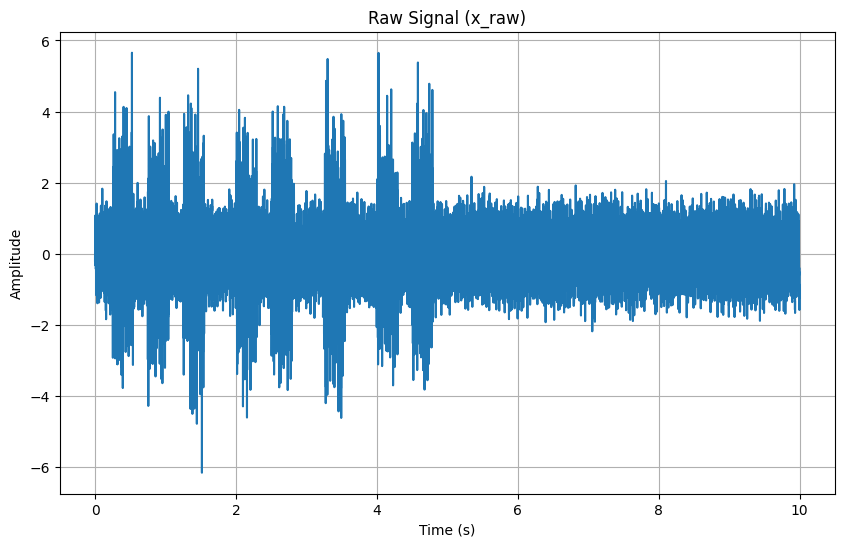

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, x_raw)
plt.title('Raw Signal (x_raw)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

B. PSD Welch

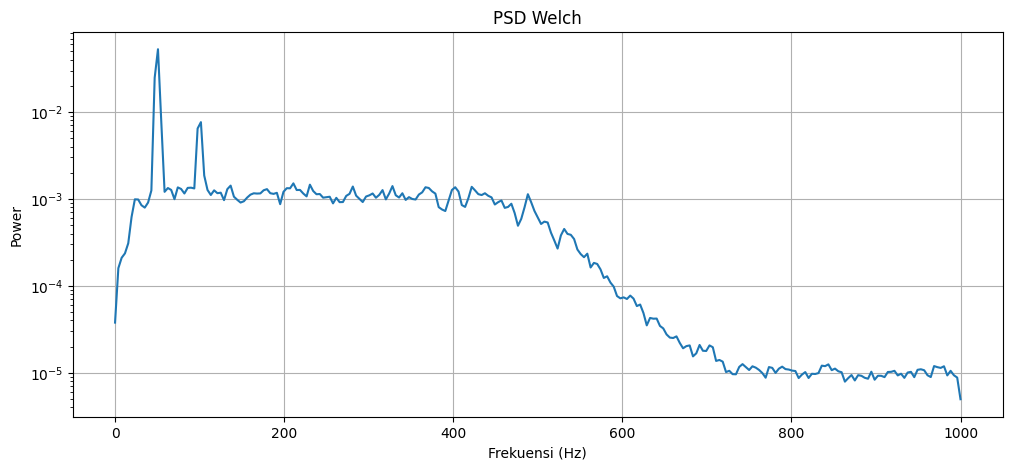

In [ ]:
f_raw, Pxx_raw = sig.welch(
    x_raw,
    fs=fs,
    nperseg=512
)

plt.figure(figsize=(12,5))

plt.semilogy(f_raw, Pxx_raw)

plt.title("PSD Welch")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Power")

plt.grid()
plt.show()

C. STFT Spectogram

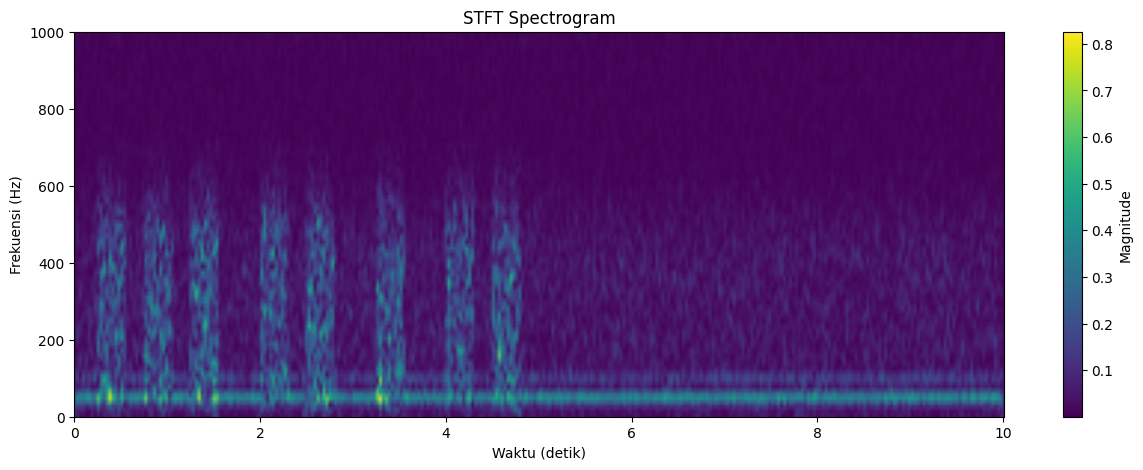

In [ ]:
f, t_stft, Zxx = sig.stft(
    x_raw,
    fs=fs,
    nperseg=128
)

plt.figure(figsize=(15,5))

plt.pcolormesh(
    t_stft,
    f,
    np.abs(Zxx),
    shading='gouraud'
)

plt.title("STFT Spectrogram")
plt.xlabel("Waktu (detik)")
plt.ylabel("Frekuensi (Hz)")

plt.colorbar(label='Magnitude')

plt.show()

## Pipeline 2 Notch Kaskade 50 + 100 Hz

A. IIR Notch

In [ ]:
Q = 30.0
bw_50 = 50.0 / Q
bw_100 = 100.0 / Q

print(f"BW Notch 50 Hz  : {bw_50:.2f} Hz")
print(f"BW Notch 100 Hz : {bw_100:.2f} Hz\n")

BW Notch 50 Hz  : 1.67 Hz
BW Notch 100 Hz : 3.33 Hz



B. Filter Notch Cascade

In [ ]:
b50, a50 = sig.iirnotch(50.0, Q, fs)
x_notch50 = sig.filtfilt(b50, a50, x_raw)
b100, a100 = sig.iirnotch(100.0, Q, fs)
x_notch_casc = sig.filtfilt(b100, a100, x_notch50)

f_notch_casc, Pxx_notch_casc = sig.welch(x_notch_casc, fs, nperseg=512)

C. Visualisasi Perbandingan Spektrum

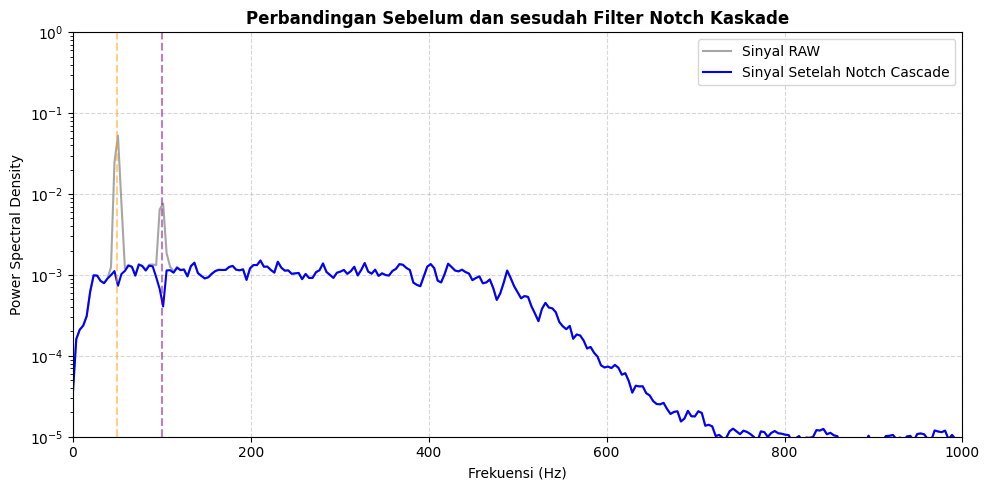

In [ ]:
plt.figure(figsize=(10, 5))
plt.semilogy(f_raw, Pxx_raw, color='gray', label='Sinyal RAW', alpha=0.7)
plt.semilogy(f_notch_casc, Pxx_notch_casc, color='blue', label='Sinyal Setelah Notch Cascade')

plt.title('Perbandingan Sebelum dan sesudah Filter Notch Kaskade', fontweight='bold')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Power Spectral Density')
plt.xlim(0, 1000)
plt.ylim(10**-5, 10**0)
plt.axvline(x=50, color='orange', linestyle='--', alpha=0.5)
plt.axvline(x=100, color='purple', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Pipeline 3 High-Pass 20 Hz (Anti Motion Artefak)

A. HPF



In [ ]:
b_hpf, a_hpf = sig.butter(4, 20, btype='highpass', fs=fs)

x_hpf = sig.filtfilt(b_hpf, a_hpf, x_notch_casc)

B. Visualisasi

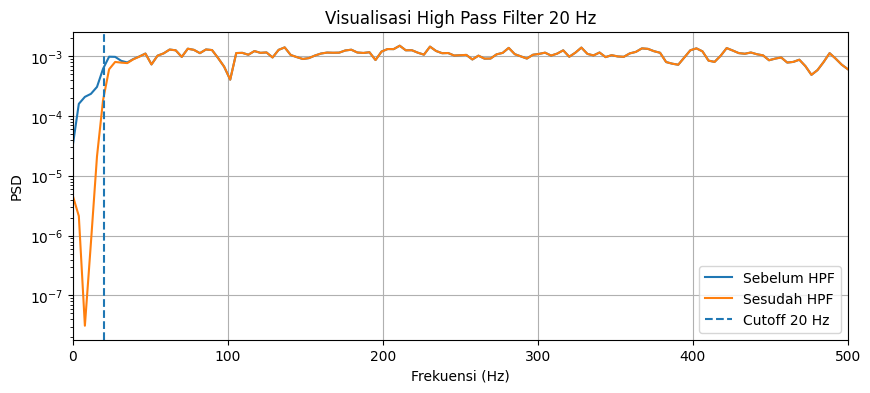

In [ ]:
f_hpf, Pxx_hpf = sig.welch(x_hpf, fs, nperseg=512)

plt.figure(figsize=(10,4))
plt.semilogy(f_notch_casc, Pxx_notch_casc, label='Sebelum HPF')
plt.semilogy(f_hpf, Pxx_hpf, label='Sesudah HPF')
plt.axvline(20, linestyle='--', label='Cutoff 20 Hz')
plt.xlim(0, 500)
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('PSD')
plt.title('Visualisasi High Pass Filter 20 Hz')
plt.legend()
plt.grid()
plt.show()

## Pipeline 4 Low-Pass 500 Hz

A. LPF

In [ ]:
b_lpf, a_lpf = sig.butter(4, 500, btype='lowpass', fs=fs)

x_lpf = sig.filtfilt(b_lpf, a_lpf, x_hpf)


B. Visualisasi

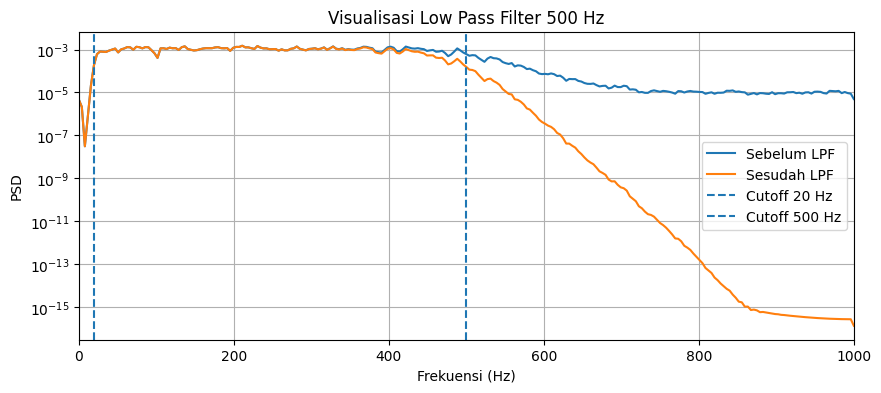

In [ ]:
f_lpf, Pxx_lpf = sig.welch(x_lpf, fs, nperseg=512)

plt.figure(figsize=(10,4))
plt.semilogy(f_hpf, Pxx_hpf, label='Sebelum LPF')
plt.semilogy(f_lpf, Pxx_lpf, label='Sesudah LPF')
plt.axvline(20, linestyle='--', label='Cutoff 20 Hz')
plt.axvline(500, linestyle='--', label='Cutoff 500 Hz')
plt.xlim(0, fs/2)
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('PSD')
plt.title('Visualisasi Low Pass Filter 500 Hz')
plt.legend()
plt.grid()
plt.show()

C. Visualisasi Akhir domain waktu

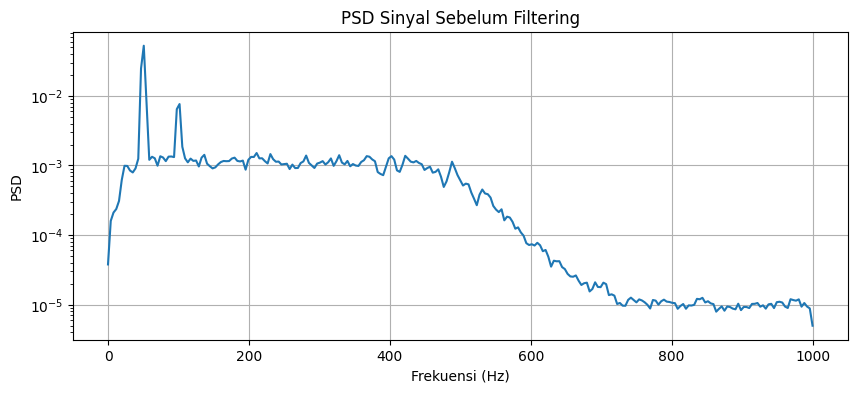

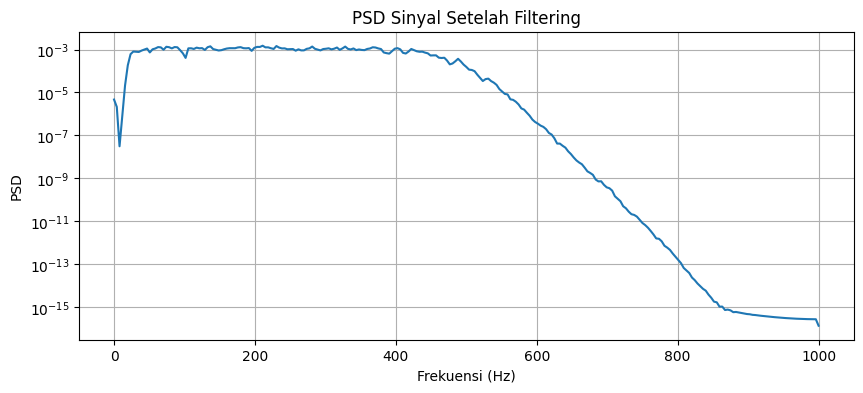

In [ ]:
x_filtered = x_lpf

plt.figure(figsize=(10,4))

plt.semilogy(f_raw, Pxx_raw)

plt.xlabel('Frekuensi (Hz)')
plt.ylabel('PSD')
plt.title('PSD Sinyal Sebelum Filtering')

plt.grid()
plt.show()
f_filtered, Pxx_filtered = sig.welch(x_lpf, fs, nperseg=512)

plt.figure(figsize=(10,4))

plt.semilogy(f_filtered, Pxx_filtered)

plt.xlabel('Frekuensi (Hz)')
plt.ylabel('PSD')
plt.title('PSD Sinyal Setelah Filtering')

plt.grid()
plt.show()

C. Visualisasi Akhir PSD

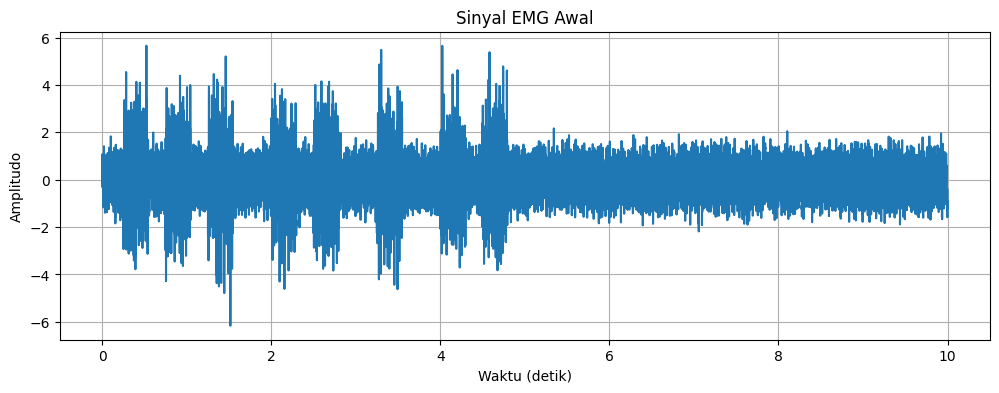

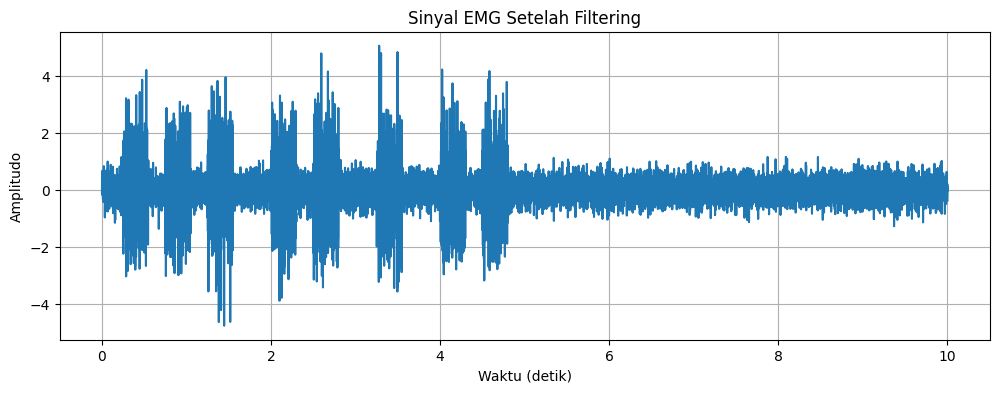

In [ ]:
time = np.arange(len(x_raw)) / fs

plt.figure(figsize=(12,4))

plt.plot(time, x_raw)

plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.title('Sinyal EMG Awal')

plt.grid()
plt.show()
time = np.arange(len(x_filtered)) / fs

plt.figure(figsize=(12,4))

plt.plot(time, x_filtered)

plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.title('Sinyal EMG Setelah Filtering')

plt.grid()
plt.show()

## Pipeline 5 Ekstraksi Fitur Real-Time

A. Frame Base Extraction

In [ ]:
window=400
hop=100
window_frame=make_sliding_frames(x_filtered,window,hop)

B. MAV

In [ ]:
window_mav=calculate_mav(window_frame)

C. RMS

In [ ]:
window_rms=calculate_rms(window_frame)

D. Visualisasi

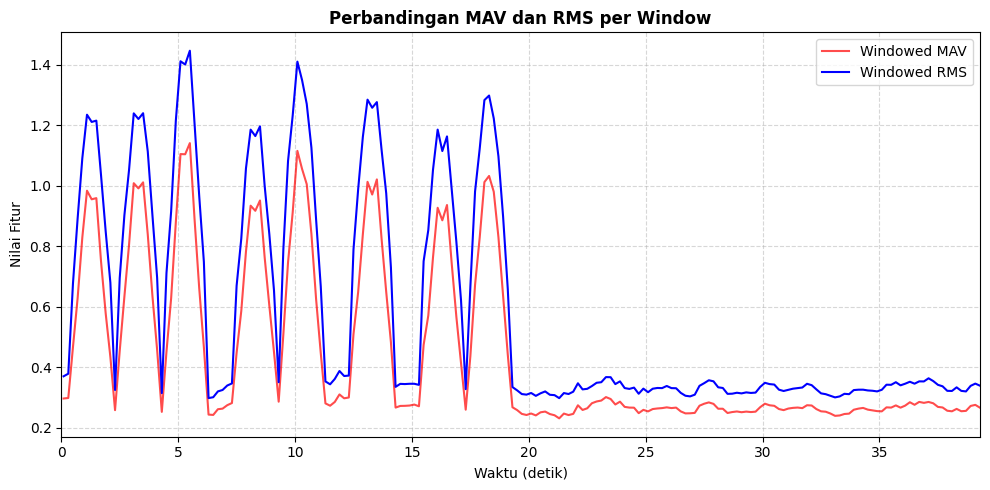

In [ ]:
t_window = (np.arange(len(window_mav)) * Window + Window/2) / fs

plt.figure(figsize=(10, 5))
plt.plot(t_window, window_mav, color='red', label='Windowed MAV', alpha=0.7)
plt.plot(t_window, window_rms, color='blue', label='Windowed RMS')

plt.title('Perbandingan MAV dan RMS per Window', fontweight='bold')
plt.xlabel('Waktu (detik)')
plt.ylabel('Nilai Fitur')
# Adjust xlim and ylim for time-domain features
plt.xlim(0, t_window.max())
# plt.ylim(ymin=0) # Let matplotlib auto-scale y-axis or set a reasonable range based on data
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Pipeline 6 Onset Detection + Frame-Based

A. WINDOW

In [ ]:
threshold=0.15
window_detection=detect_onset(window_mav, threshold)
window_ground_truth=ground_truth_burst(burst_mask,window,hop)
window_calculate=calculate_confusion_matrix(window_detection,window_ground_truth)
print("Window Calculate")
print("TP=", window_calculate[0])
print("FP=", window_calculate[1])
print("TN=", window_calculate[2])
print("FN=", window_calculate[3])
print("Ground Truth Burst=",sum(window_ground_truth),"dari",len(window_ground_truth))


Window Calculate
TP= 72
FP= 125
TN= 0
FN= 0
Ground Truth Burst= 72 dari 197


# Pertanyaan Analisis


1.Notch 50 Hz dan 100 Hz keduanya diaplikasikan pada fs=2000 Hz. Hitung BW masing-
masing. Hitung berapa persen energi EMG yang hilang akibat kedua notch (integrasikan

respons frekuensi filter di band 20–500 Hz). Apakah ini signifikan?


Persentase energi filter teoritis hilang pada band 20-500 Hz: 1.63%
Persentase energi sinyal EMG hilang pada band 20-500 Hz: 42.77%


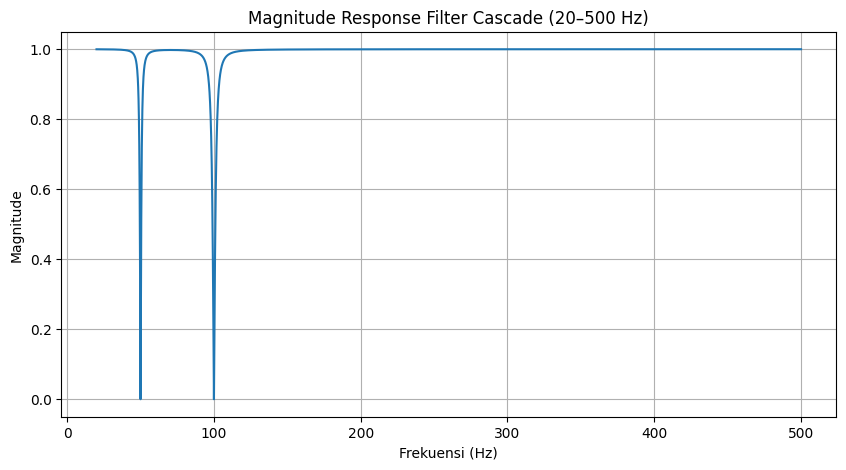

3778.5255224775624


In [ ]:
print(f"BW Notch 50 Hz  : {bw_50:.2f} Hz")
print(f"BW Notch 100 Hz : {bw_100:.2f} Hz\n")

b_casc = np.convolve(b50, b100)
a_casc = np.convolve(a50, a100)
w, h = sig.freqz(b_casc, a_casc, fs=fs, worN=8000)
band_lim = (w >= 20) & (w <= 500)
h_band = h[band_lim]
power_response = np.abs(h_band)**2
ideal_energy = len(power_response) * 1.0
actual_energy = np.sum(power_response)
percent_lost = (1 - (actual_energy / ideal_energy)) * 100
band_psd_raw = (f_raw >= 20) & (f_raw <= 500)
band_psd_filter = (f_notch_casc >= 20) & (f_notch_casc <= 500)
energi_x_raw = np.trapezoid(Pxx_raw[band_psd_raw], f_raw[band_psd_raw])
energi_x_filter = np.trapezoid(Pxx_sesudah[band_psd_filter], f_sesudah[band_psd_filter])
energi_x_filter_percent = (1 - (energi_x_filter / energi_x_raw)) * 100
print(f"Persentase energi filter teoritis (jika Penyebarannya rata) hilang pada band 20-500 Hz: {percent_lost:.2f}%")
print(f"Persentase energi sinyal EMG hilang pada band 20-500 Hz: "f"{energi_x_filter_percent:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(w[band_lim], np.abs(h_band))
plt.title('Magnitude Response Filter Cascade (20–500 Hz)')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)

plt.show()


2.Onset detection: hitung Sensitivity = TP/(TP+FN) dan Specificity = TN/(TN+FP) dari sistem
deteksi Anda. Berapa nilai optimal threshold MAV yang memaksimalkan (Sensitivity +
Specificity)?

In [ ]:
window_Performance=performance(window_calculate)
print("Sensivity=",window_Performance[0])
print("Specify=",window_Performance[1])

Hasil pengujian menunjukkan bahwa nilai sensitivity sebesar 1.0 atau 100%, yang berarti seluruh sinyal EMG aktif (burst) berhasil terdeteksi oleh sistem tanpa ada aktivitas otot yang terlewat. Hal ini menunjukkan bahwa metode deteksi memiliki kemampuan yang sangat baik dalam mengenali kondisi aktif. Namun, nilai specificity sebesar 0.0 menunjukkan bahwa sistem tidak mampu mengenali kondisi non-aktif dengan baik. Semua kondisi diam atau tidak ada aktivitas otot justru terdeteksi sebagai aktif sehingga menghasilkan false positive yang tinggi. Kondisi ini biasanya terjadi karena nilai threshold yang digunakan terlalu rendah sehingga noise atau sinyal kecil masih dianggap sebagai aktivitas otot. Oleh karena itu, meskipun sensitivity sangat baik, performa sistem secara keseluruhan masih perlu diperbaiki terutama pada kemampuan membedakan sinyal aktif dan non-aktif dengan menaikkan threshold atau melakukan optimasi fitur deteksi.


In [ ]:
window_find_best_threshold=find_best_threshold(window_mav, window_ground_truth,1)
print("Best Threshold=",window_find_best_threshold[0])
print("Sensitivity=",window_find_best_threshold[1])
print("Specify=",window_find_best_threshold[2])

Hasil pengujian menunjukkan bahwa threshold terbaik diperoleh pada nilai 0.32 dengan sensitivity sebesar 0.1806 dan specificity sebesar 1.0. Nilai specificity yang mencapai 100% menunjukkan bahwa sistem sangat baik dalam mengenali kondisi non-aktif atau diam, sehingga tidak menghasilkan false positive. Namun, sensitivity yang rendah menunjukkan bahwa sistem hanya mampu mendeteksi sebagian kecil aktivitas otot yang sebenarnya terjadi. Hal ini berarti banyak sinyal burst EMG yang tidak terdeteksi atau dianggap non-aktif. Kondisi tersebut menunjukkan bahwa threshold 0.32 terlalu tinggi sehingga sistem menjadi terlalu ketat dalam mendeteksi aktivitas EMG. Akibatnya, meskipun kesalahan deteksi noise dapat diminimalkan, banyak aktivitas otot yang justru terlewat. Oleh karena itu, pemilihan threshold perlu diseimbangkan agar sensitivity dan specificity dapat sama-sama memiliki nilai yang baik sesuai kebutuhan aplikasi prostetik.

3. Fitur MAV vs RMS: hitung korelasi Pearson antara time-series MAV dan RMS dari sliding
window. Apakah keduanya mengandung informasi yang sama? Dalam aplikasi prostetik, fitur
mana yang lebih baik dan mengapa?

In [ ]:
from scipy.stats import pearsonr

r, p_value = pearsonr(window_mav, window_rms)

print("Pearson r =", r)
print("P-value =", p_value)

Hasil perhitungan menunjukkan bahwa korelasi Pearson antara fitur MAV dan RMS sebesar 0.992, yang berarti keduanya memiliki hubungan linear yang sangat kuat dan hampir identik. Nilai ini mendekati 1 sehingga menunjukkan bahwa ketika nilai MAV meningkat, nilai RMS juga meningkat dengan pola yang hampir sama pada setiap sliding window. Selain itu, nilai p-value yang sangat kecil, yaitu sekitar 3.13x10^{-177} menunjukkan bahwa korelasi tersebut sangat signifikan secara statistik dan bukan terjadi secara kebetulan. Hal ini membuktikan bahwa fitur MAV dan RMS mengandung informasi yang hampir sama dalam merepresentasikan aktivitas otot pada sinyal EMG.
Meskipun demikian, terdapat perbedaan karakteristik antara keduanya. MAV menghitung rata-rata nilai absolut sinyal sehingga lebih sederhana dan ringan secara komputasi. RMS menghitung akar dari rata-rata kuadrat sinyal sehingga lebih sensitif terhadap amplitudo besar dan lebih merepresentasikan energi sinyal EMG. Dalam aplikasi prostetik real-time, MAV sering lebih dipilih karena perhitungannya cepat dan efisien untuk mikrokontroler dengan sumber daya terbatas. Namun, RMS dapat memberikan representasi kekuatan kontraksi otot yang lebih baik apabila sistem memiliki kemampuan komputasi yang cukup. Karena korelasi keduanya sangat tinggi, penggunaan salah satu fitur saja umumnya sudah cukup untuk proses deteksi atau klasifikasi gerakan pada sistem prostetik.

4. Frame size 50 ms: berapa latensi sistem dari onset kontraksi ke deteksi output? Standar
prostetik memerlukan latensi < 300 ms agar terasa natural. Apakah sistem Anda memenuhi
syarat ini?

Dengan frame size sebesar 50 ms, sistem membutuhkan waktu sekitar 50 ms untuk mengumpulkan data sinyal EMG sebelum fitur seperti MAV atau RMS dihitung dan deteksi onset dilakukan. Oleh karena itu, latensi dari awal kontraksi otot hingga keluaran deteksi sistem secara ideal berada di sekitar 50 ms. Jika ditambahkan waktu pemrosesan komputasi, latensi total kemungkinan masih berada pada kisaran 50–100 ms. Nilai ini masih jauh di bawah batas standar prostetik yaitu 300 ms, sehingga sistem dapat dikatakan memenuhi syarat latensi dan berpotensi terasa cukup natural saat digunakan.

5. Efek motion artefak pada akurasi onset detection: bandingkan onset detection DENGAN dan
TANPA high-pass filter (fc=20 Hz). Berapa TP yang berubah? Kuantifikasi kontribusi noise
motion artefak terhadap false positive rate.

In [ ]:
threshold=0.32
window_thpf_mkf=make_sliding_frames(x_notch_casc, window, hop)
window_thpf_mav=calculate_mav(window_thpf_mkf)
window_thpf_detect_onset=detect_onset(window_thpf_mav, threshold)
window_thpf_ground_truth=ground_truth_burst(burst_mask, window, hop)
window_thpf_calculate=calculate_confusion_matrix(window_thpf_detect_onset,window_thpf_ground_truth)
print("Window Tanpa High Pas Filtering Calculate")
print("TP=", window_thpf_calculate[0])
print("FP=", window_thpf_calculate[1])
print("TN=", window_thpf_calculate[2])
print("FN=", window_thpf_calculate[3],"\n")

window_shpf_mkf=make_sliding_frames(x_hpf, window, hop)
window_shpf_calculate_mav=calculate_mav(window_shpf_mkf)
window_shpf_detect_onset=detect_onset(window_shpf_calculate_mav, threshold)
window_shpf_ground_truth=ground_truth_burst(burst_mask, window, hop)
window_shpf_calculate=calculate_confusion_matrix(window_shpf_detect_onset,window_shpf_ground_truth)
print("Window Dengan High Pas Filtering Calculate")
print("TP=", window_shpf_calculate[0])
print("FP=", window_shpf_calculate[1])
print("TN=", window_shpf_calculate[2])
print("FN=", window_shpf_calculate[3])




Pada pengujian onset detection dengan threshold 0.15, sistem menghasilkan true positive sebesar 72, false positive sebesar 125, true negative sebesar 0, dan false negative sebesar 0, baik sebelum maupun sesudah penggunaan high-pass filter 20 Hz. Hal ini menunjukkan bahwa penggunaan high-pass filter pada threshold tersebut tidak memberikan perubahan terhadap hasil deteksi. Sistem berhasil mendeteksi seluruh aktivitas otot sehingga sensitivity bernilai sangat tinggi, tetapi semua kondisi non-aktif juga terdeteksi sebagai aktif sehingga false positive sangat besar dan specificity menjadi sangat rendah. Kondisi ini menunjukkan bahwa threshold 0.15 terlalu rendah sehingga noise dan sinyal kecil masih dianggap sebagai aktivitas EMG. Akibatnya, pengaruh motion artefak tidak dapat diamati dengan jelas karena hampir seluruh frame telah terdeteksi aktif sejak awal.
Sedangkan pada threshold 0.32, performa sistem menjadi lebih baik. Tanpa high-pass filter, sistem menghasilkan true positive sebesar 72, false positive sebesar 7, true negative sebesar 118, dan false negative sebesar 0. Setelah penggunaan high-pass filter 20 Hz, true positive tetap 72 dan false negative tetap 0, namun false positive menurun dari 7 menjadi 3 dan true negative meningkat dari 118 menjadi 122. Hal ini menunjukkan bahwa high-pass filter berhasil mengurangi noise frekuensi rendah atau motion artefak yang sebelumnya menyebabkan beberapa kondisi non-aktif salah terdeteksi sebagai aktif. Penurunan false positive sebanyak 4 menunjukkan bahwa motion artefak memang memberikan kontribusi terhadap kesalahan deteksi pada sistem tanpa high-pass filter. Selain itu, false positive rate juga menurun dari sekitar 5.6% menjadi sekitar 2.4% setelah penggunaan high-pass filter. Dengan demikian, penggunaan threshold yang lebih tepat dikombinasikan dengan high-pass filter 20 Hz mampu meningkatkan kemampuan sistem dalam membedakan kondisi aktif dan non-aktif tanpa mengurangi kemampuan deteksi onset EMG.
